In [1]:
# Array and data functions
from glob import glob
import numpy as np
import pandas as pd

# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler, ConfIntSampler

from scipy.stats import tukey_hsd, kruskal

from tqdm import tqdm
from skimage import io

import warnings
warnings.filterwarnings('ignore')

In [2]:
### Get the sample list
!wget = 'https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/354/S-BIAD2354/Files/submission_%20cell_inference_Fig6.tsv'

samples = pd.read_table('submission_ cell_inference_Fig6.tsv')

--2026-02-10 12:26:00--  http://=/
Resolving = (=)... failed: nodename nor servname provided, or not known.
wget: unable to resolve host address ‘=’
--2026-02-10 12:26:00--  https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/354/S-BIAD2354/Files/submission_%20cell_inference_Fig6.tsv
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14298 (14K) [text/tab-separated-values]
Saving to: ‘submission_ cell_inference_Fig6.tsv.4’

submission_ cell_in 100%[===================>]  13,96K  --.-KB/s    in 0s      

2026-02-10 12:26:00 (35,2 MB/s) - ‘submission_ cell_inference_Fig6.tsv.4’ saved [14298/14298]

FINISHED --2026-02-10 12:26:00--
Total wall clock time: 0,2s
Downloaded: 1 files, 14K in 0s (35,2 MB/s)


In [3]:
### Get the cell IDs
images = np.array(samples['Files'])

### For this study specifically, we recommend to create a directory and save the images there. We use this name as it will be the same as on the online repo
!mkdir ponA_inductions_masks

basedir = 'https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/354/S-BIAD2354/Files/'

for i in tqdm(range(len(images))):

    img_name = images[i]

    img = io.imread(f'{basedir}{img_name}')
    
    io.imsave(fname=img_name,arr=img)


mkdir: ponA_inductions_masks: File exists


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.77it/s]


In [4]:
BasePath ='ponA_inductions_masks/' 

images = sorted(glob(BasePath+'*.tif'))

strains = np.unique([img.split('/')[-1].split('_')[0] for img in images])

print(strains)

print(f'Total images: {len(images)}')

['JLG1561' 'JLG6822' 'JLG6872']
Total images: 100


In [5]:
dfs = []

for s in strains:

    images = sorted(glob(f'{BasePath}{s}*.tif'))

    iptg = np.unique([img.split('/')[-1].split('_')[1] for img in images])

    for i in iptg:

        masks = sorted(glob(f'{BasePath}{s}_{i}_*.tif'))
        df = SizeDataFrame(masks)
        
        df.insert(0,'Strain',s)
        df.insert(1,'IPTG',i)

        dfs.append(df)

dfs = pd.concat(dfs,ignore_index=True)
dfs = dfs[dfs['Width'] > 0.3]

In [6]:
metrics = ['Length','Width','SurfaceArea','Volume']
columns = ['Strain','IPTG']
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS8_posterior_segmentation_measurements.csv')

final_df = ParamSampler(dfs,df_posteriors,columns,metrics)

w = ConfIntSampler(final_df,columns=['Strain','IPTG'],metric='Width_mu',interval=0.99)
L = ConfIntSampler(final_df,columns=['Strain','IPTG'],metric='Length_mu',interval=0.99)

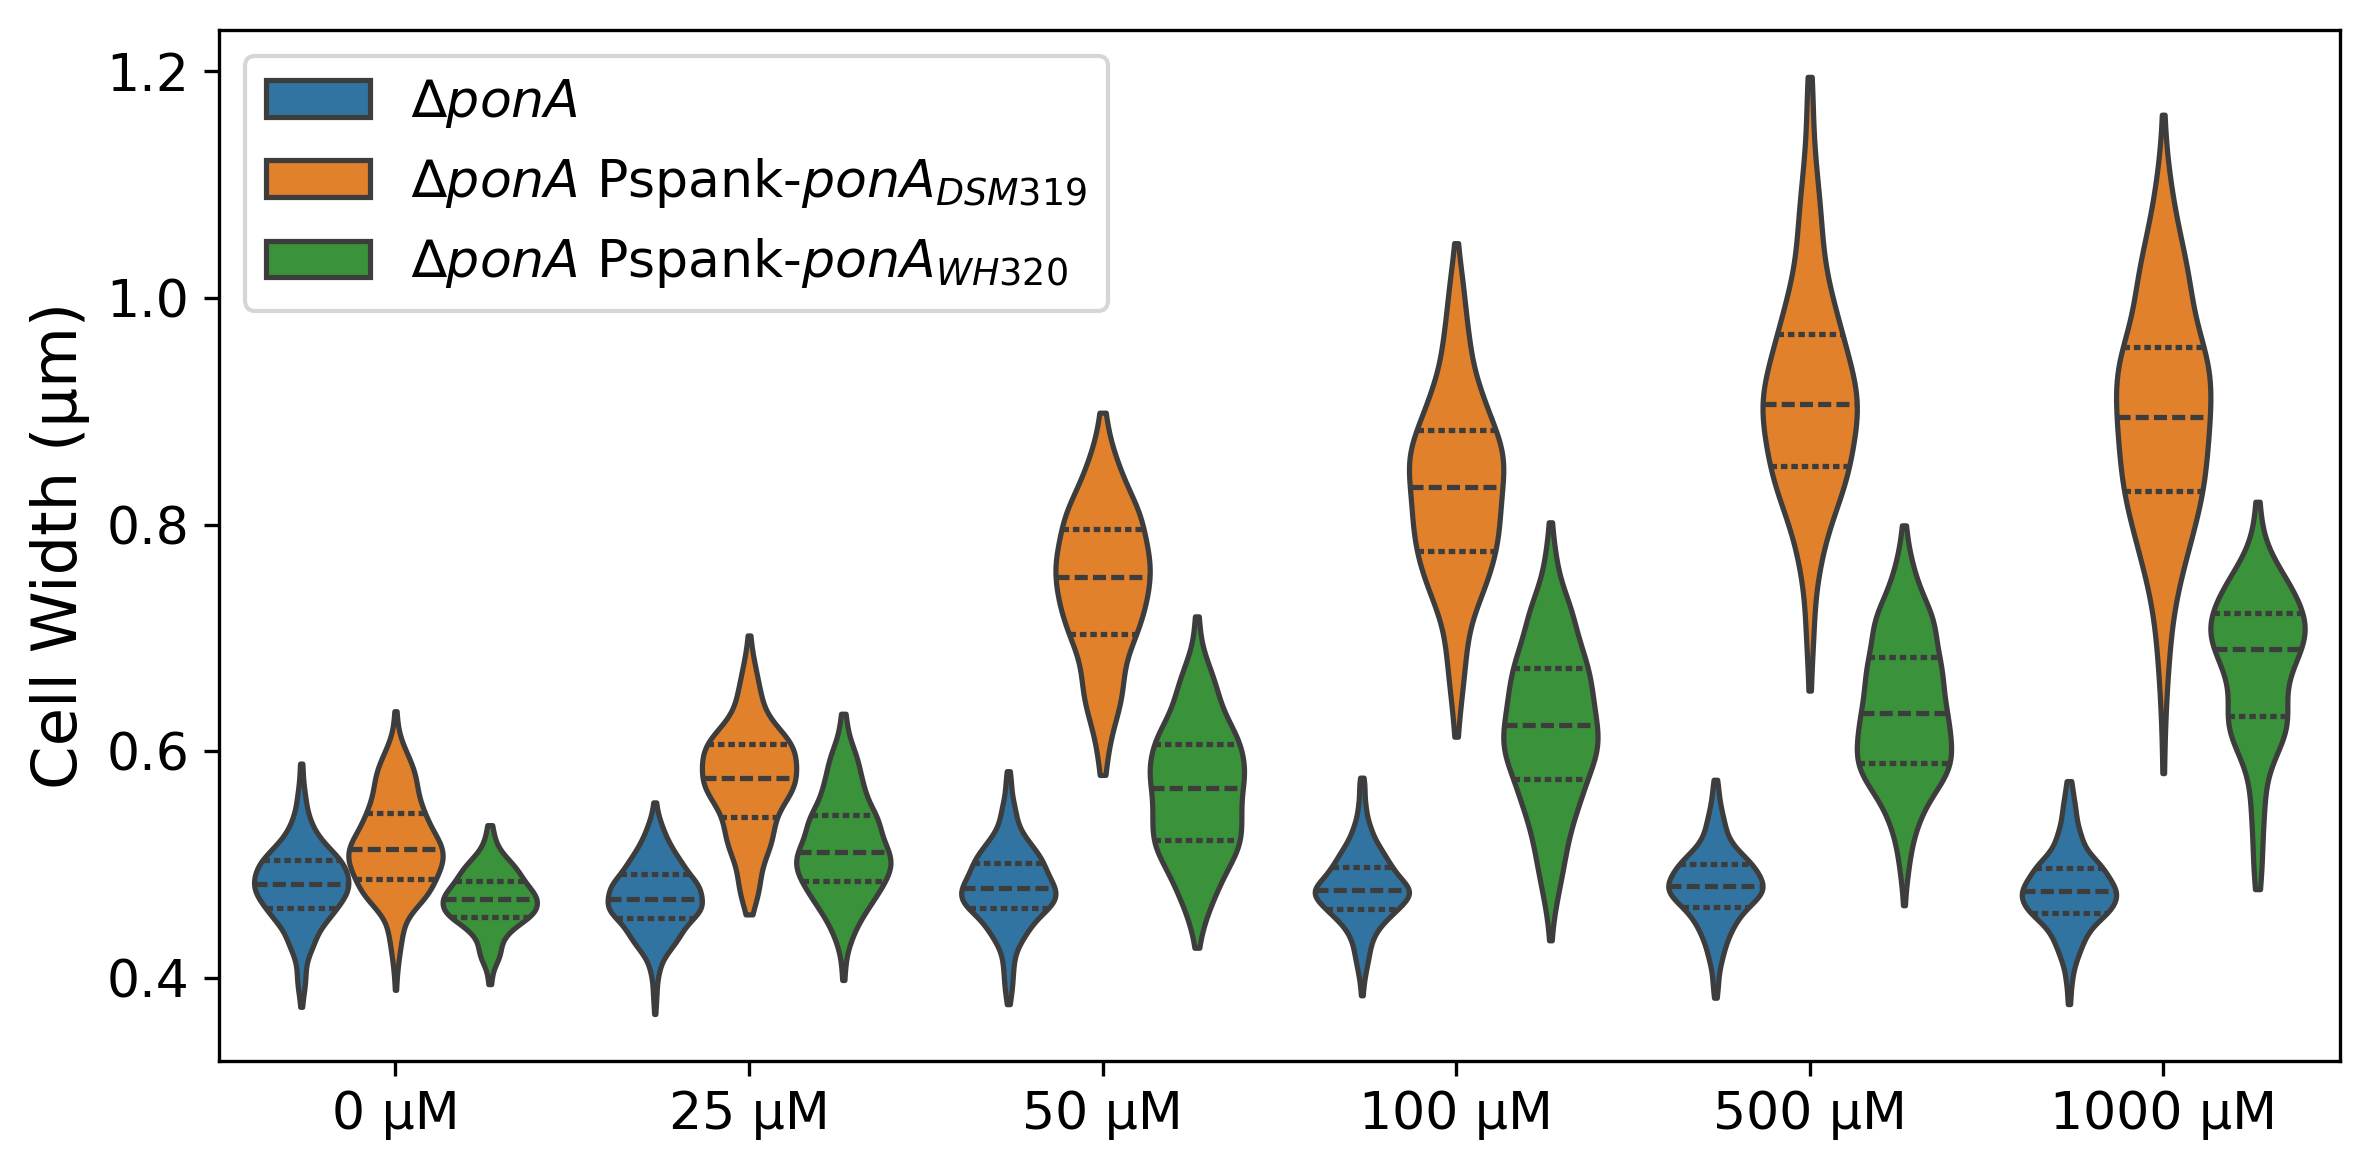

In [5]:
fig,ax = plt.subplots(dpi=300,figsize=(8,4))

strain_order = ['JLG1561','JLG6872','JLG6822']

labels = ['∆$ponA$','∆$ponA$ Pspank-$ponA_{DSM319}$','∆$ponA$ Pspank-$ponA_{WH320}$']

xticklabs = [0,25,50,100,500,1000]
xticklabs2 = [f'{x} µM' for x in xticklabs]

sns.violinplot(x=w['IPTG'],y=w['Width_mu'],order=['0uM','25uM','50uM','100uM','500uM','1000uM'],hue=w['Strain'],ax=ax,hue_order=strain_order,inner='quart',scale='width',cut=0)
ax.set_xticklabels(xticklabs2,fontsize=12.5)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5)
ax.set_xlabel('')
ax.set_ylabel('Cell Width (µm)',fontsize=15)
ax.legend(title=None,labels=labels,handles=ax.get_legend_handles_labels()[0],fontsize=12.5)

fig.tight_layout()
#fig.savefig('ponA_inductions_width.png')

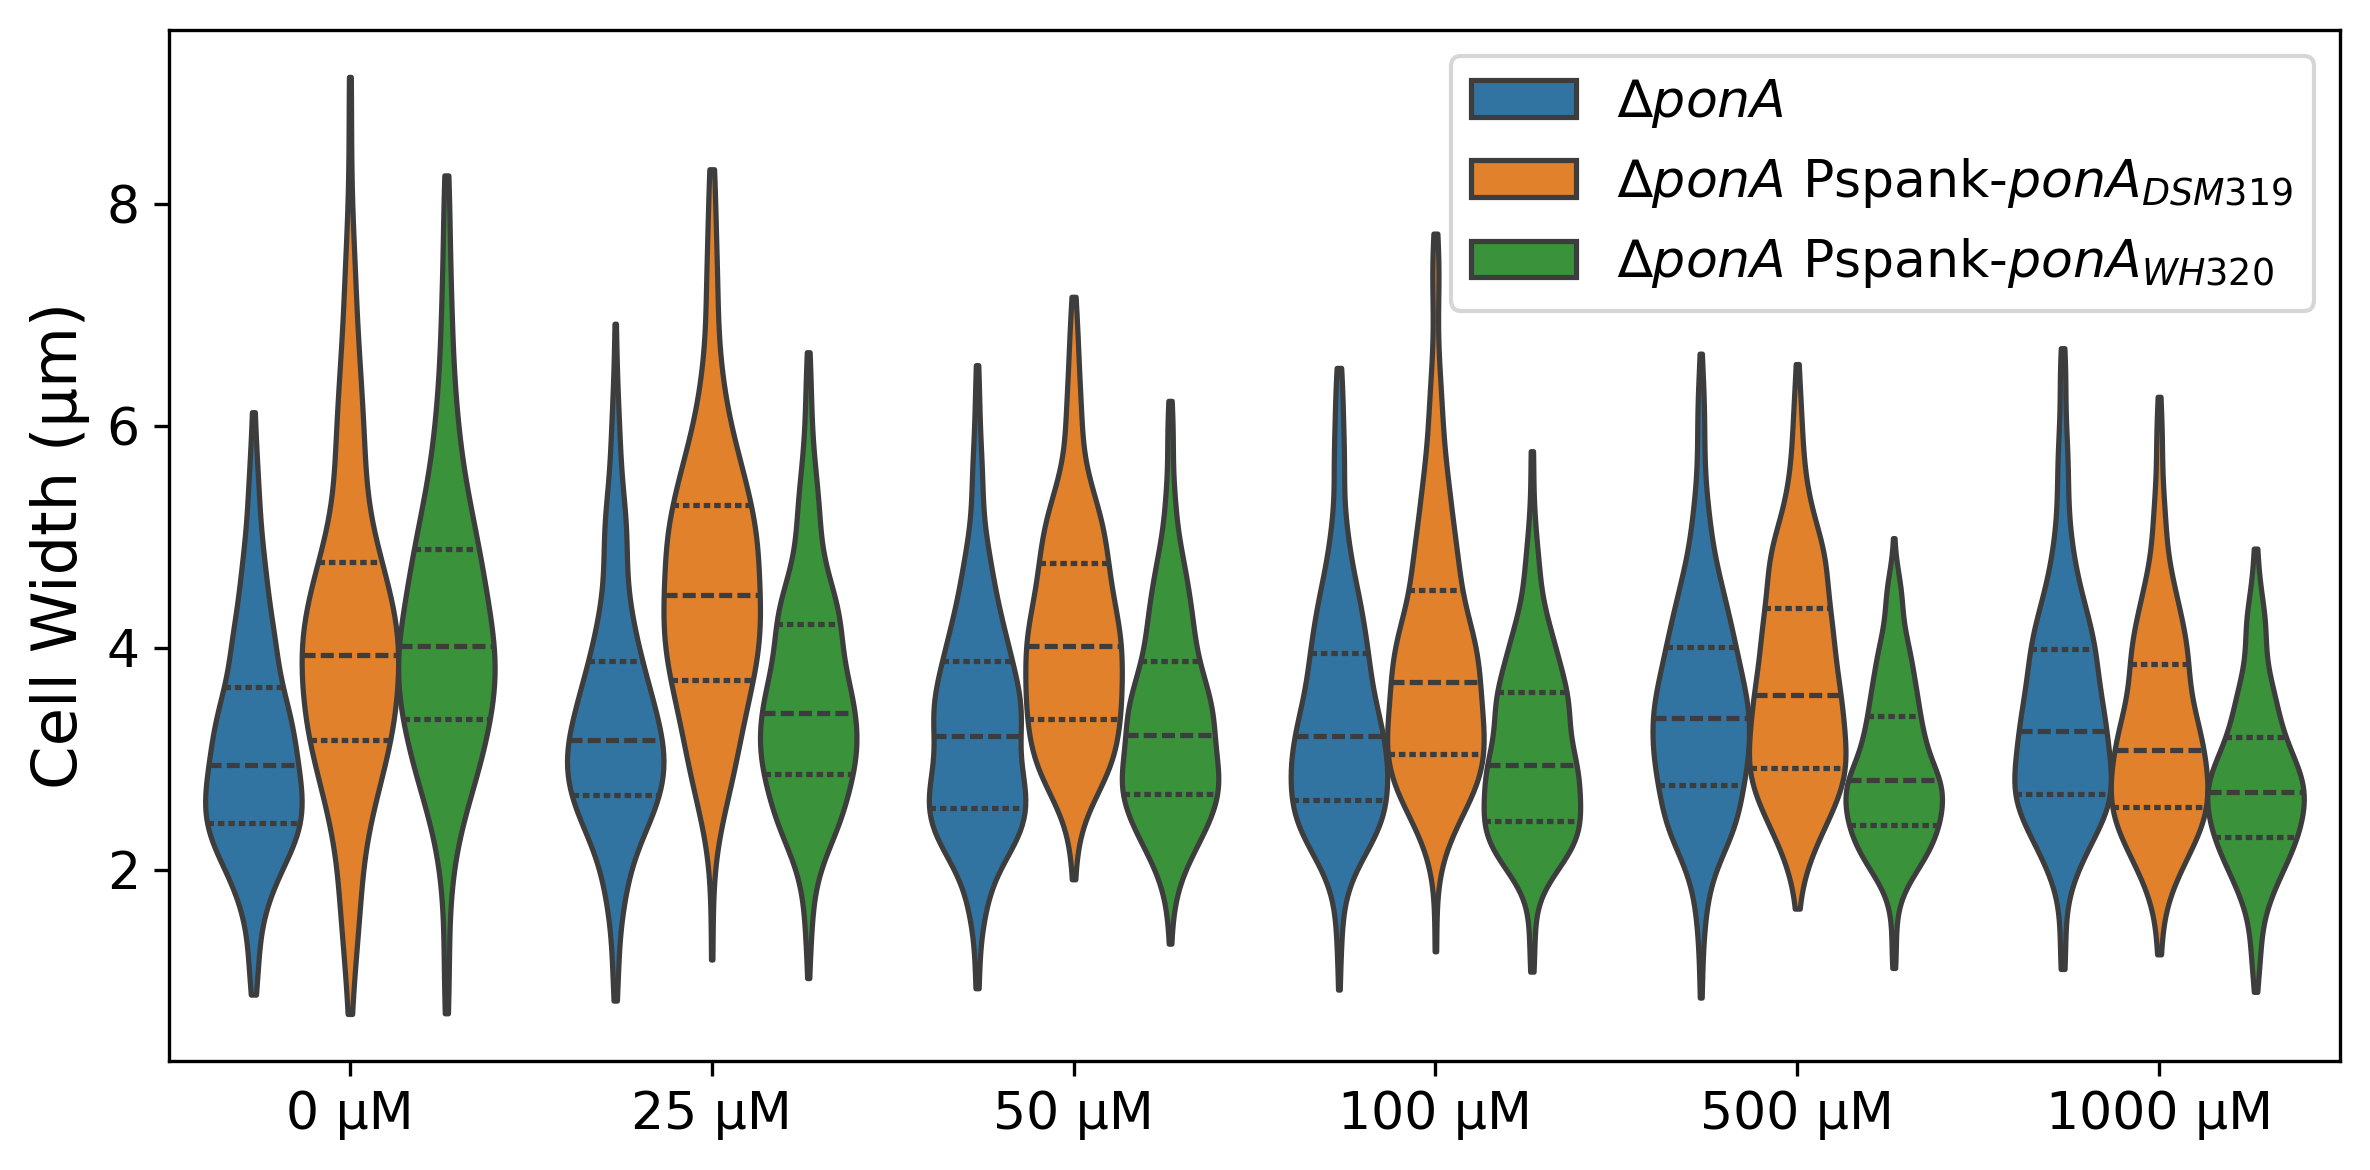

In [6]:
fig,ax = plt.subplots(dpi=300,figsize=(8,4))

strain_order = ['JLG1561','JLG6872','JLG6822']

labels = ['∆$ponA$','∆$ponA$ Pspank-$ponA_{DSM319}$','∆$ponA$ Pspank-$ponA_{WH320}$']

xticklabs = [0,25,50,100,500,1000]
xticklabs2 = [f'{x} µM' for x in xticklabs]

sns.violinplot(x=L['IPTG'],y=L['Length_mu'],order=['0uM','25uM','50uM','100uM','500uM','1000uM'],hue=L['Strain'],ax=ax,hue_order=strain_order,inner='quart',scale='width',cut=0)
ax.set_xticklabels(xticklabs2,fontsize=12.5)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5)
ax.set_xlabel('')
ax.set_ylabel('Cell Width (µm)',fontsize=15)
ax.legend(title=None,labels=labels,handles=ax.get_legend_handles_labels()[0],fontsize=12.5)

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/ponA_inductions_length.png')

In [9]:
df = pd.read_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/Fig6_width_violins.csv')

### Tukey HSD comparing size in each induction level

In [11]:
np.unique(w['IPTG'])

array([np.str_('0uM'), np.str_('1000uM'), np.str_('100uM'),
       np.str_('25uM'), np.str_('500uM'), np.str_('50uM')], dtype=object)

In [14]:
for i in np.unique(w['Strain']):

    subdf = w[w['Strain'] == i]

    s1 = np.array(subdf[subdf['IPTG'] == '0uM']['Width_mu'])
    s2 = np.array(subdf[subdf['IPTG'] == '25uM']['Width_mu'])
    s3 = np.array(subdf[subdf['IPTG'] == '50uM']['Width_mu'])
    s4 = np.array(subdf[subdf['IPTG'] == '100uM']['Width_mu'])
    s5 = np.array(subdf[subdf['IPTG'] == '500uM']['Width_mu'])
    s6 = np.array(subdf[subdf['IPTG'] == '1000uM']['Width_mu'])

    print(f'Strain = {i}')
    print(tukey_hsd(s1,s2,s3,s4,s5,s6))
    print('\n')


Strain = JLG1561
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.011     0.000     0.005     0.017
 (0 - 2)      0.002     0.956    -0.004     0.007
 (0 - 3)      0.003     0.663    -0.003     0.008
 (0 - 4)      0.001     0.998    -0.005     0.007
 (0 - 5)      0.005     0.181    -0.001     0.011
 (1 - 0)     -0.011     0.000    -0.017    -0.005
 (1 - 2)     -0.009     0.000    -0.015    -0.004
 (1 - 3)     -0.008     0.000    -0.014    -0.003
 (1 - 4)     -0.010     0.000    -0.016    -0.004
 (1 - 5)     -0.006     0.020    -0.012    -0.001
 (2 - 0)     -0.002     0.956    -0.007     0.004
 (2 - 1)      0.009     0.000     0.004     0.015
 (2 - 3)      0.001     0.986    -0.004     0.006
 (2 - 4)     -0.001     0.998    -0.006     0.005
 (2 - 5)      0.003     0.590    -0.002     0.008
 (3 - 0)     -0.003     0.663    -0.008     0.003
 (3 - 1)      0.008     0.000     0.003     0.014
 (3 - 2)     -0